In [213]:
import psycopg2
import pandas as pd
from math import ceil, floor
from time import sleep
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [2]:
POSTGRES_CONFIG = {
    'host': 'localhost',
    'port': '5430',
    'dbname': 'dwh',
    'user': 'user',
    'password': 'pwd',
}


In [3]:
def connect_to_db():
    print("Creating PostgreSQL connection...")
    while True:
        print("Trying to connect...")
        try:
            conn = psycopg2.connect(**POSTGRES_CONFIG)
            cur = conn.cursor()
            cur.execute('''SELECT version()''')
            version = cur.fetchone()
            print(f"PostgreSQL connection created! Version: {version}")
            return conn, cur

        except Exception as e:
            print(f"db connection failed:\n{e}")
            print("Retry connection after 5 sec...")
            sleep(5)

In [4]:
conn, cur = connect_to_db()

Creating PostgreSQL connection...
Trying to connect...
PostgreSQL connection created! Version: ('PostgreSQL 15.15 on x86_64-pc-linux-musl, compiled by gcc (Alpine 15.2.0) 15.2.0, 64-bit',)


In [5]:
def select(cursor):
    query = """select * from bulls_fact bf
    inner join dim_car dc on dc.car_key = bf.car_key
    inner join dim_condition dcd on dcd.condition_key = bf.condition_key
    """
    cursor.execute(query)
    return cursor.fetchall()

In [6]:
bulls_joined = select(cur)

In [7]:
bulls_df = pd.DataFrame(bulls_joined, 
    columns=["event_id", "time_received", "bull_id", "bull_hash", "mileage", "price_rub", "location", "num_of_owners", 
             "num_of_previous_bulls", "car_key", "date_key", "condition_key", "car_key1", "manufacturer", "model", "year",
             "engine_capacity", "engine_power", "engine_type", "transmission_type", "wheel_drive", "steering", "color",
             "condition_key1", "by_order", "from_owner", "is_new", "no_mileage_in_russia", "is_broken", "no_docs", "passport_issues",
             "owned_by_company", "has_penalties"
            ]
    )

In [8]:
bulls_df = bulls_df.drop(
        columns=["event_id", "time_received", "bull_id", "bull_hash", "car_key", "date_key", "condition_key",
            "car_key1", "condition_key1"])

In [9]:
bulls_df

,mileage,price_rub,location,num_of_owners,num_of_previous_bulls,manufacturer,model,year,engine_capacity,engine_power,...,color,by_order,from_owner,is_new,no_mileage_in_russia,is_broken,no_docs,passport_issues,owned_by_company,has_penalties
0,160000.0,260000,Омск,6.0,11.0,Лада,2114 Самара,2012,1.6,89.0,...,черный,False,False,False,False,False,False,False,False,False
1,288890.0,899000,Омск,5.0,2.0,Ford,Focus,2010,2.0,145.0,...,серебристый,False,False,False,False,False,False,False,False,False
2,247000.0,1390000,Омск,4.0,5.0,Honda,CR-V,2008,2.0,150.0,...,серый,False,False,False,False,False,False,False,False,False
3,222000.0,1800000,Омск,3.0,NaN,BMW,X3,2011,3.0,258.0,...,белый,False,True,False,False,False,False,False,False,False
4,139000.0,283000,Омск,8.0,9.0,Лада,Приора,2011,1.6,98.0,...,NaN,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
986,378000.0,350000,Омск,NaN,NaN,Honda,Fit,2006,1.3,86.0,...,серебристый,False,False,False,False,True,False,False,False,False
987,270000.0,450000,Омск,3.0,3.0,Toyota,Vitz,2002,1.0,70.0,...,синий,False,True,False,False,False,False,False,False,False
988,190000.0,1450000,Омск,2.0,3.0,Mazda,6,2012,2.5,192.0,...,белый,False,False,False,False,False,False,False,False,False
989,144111.0,400000,Омск,3.0,NaN,Datsun,on-DO,2014,1.6,87.0,...,серый,False,False,False,False,False,False,False,False,False


In [283]:
bulls_df.describe()

,mileage,price_rub,num_of_owners,num_of_previous_bulls,year,engine_power
count,962.000000,9.910000e+02,876.000000,611.000000,991.000000,985.000000
mean,181951.355509,1.348879e+06,3.506849,4.813421,2010.984864,141.675127
std,106469.614785,1.745582e+06,2.194788,3.159874,7.711514,63.583151
min,10.000000,4.700000e+04,1.000000,2.000000,1981.000000,51.000000
25%,100000.000000,4.625000e+05,2.000000,2.000000,2006.000000,100.000000
50%,183000.000000,8.950000e+05,3.000000,4.000000,2011.000000,124.000000
75%,249617.250000,1.634500e+06,5.000000,6.000000,2017.000000,160.000000
max,828000.000000,2.400000e+07,15.000000,22.000000,2026.000000,560.000000


In [272]:
def show_distribution(df, column_name, year, n_years, n_bins=10, formatter=None, xmax=None):
    bulls_series = df.query("year > @year - @n_years / 2 and year < @year + @n_years / 2")[column_name]
    series_desc = bulls_series.describe()

    fig, ax = plt.subplots(figsize=(8,5))
    n, bins, patches = ax.hist(bulls_series, n_bins, density=True, alpha=0.6, color='skyblue', label='histogram')

    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    rolling_avg_counts = pd.Series(n).rolling(window=2, center=True, min_periods=1).mean()

    ax.plot(bin_centers, rolling_avg_counts, color='red', linewidth=1, label='average density')
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.set_title(f'{column_name} distribution ({ceil(year - n_years / 2)}-{floor(year + n_years / 2)} years prod.)')
    ax.axvline(x=series_desc['mean'], linestyle='--', color='blue', label='mean')
    ax.axvline(x=series_desc['mean'] + series_desc['std'], linestyle='--', color='green', label='mean+-std')
    ax.axvline(x=series_desc['mean'] - series_desc['std'], linestyle='--', color='green', label=None)
    if formatter:
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(thousands_formatter))
    if xmax:
        ax.set_xlim(0, xmax)
    ax.legend()
    plt.tight_layout()
    plt.show()

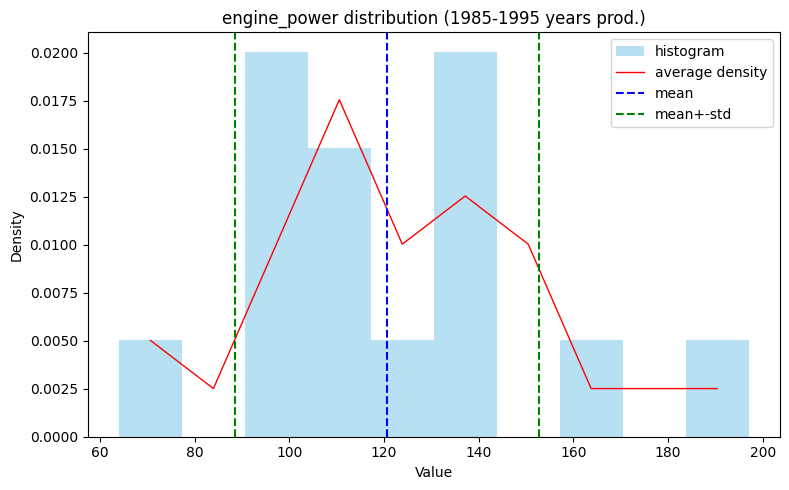

In [273]:
show_distribution(bulls_df, 'engine_power', 1990, 10)

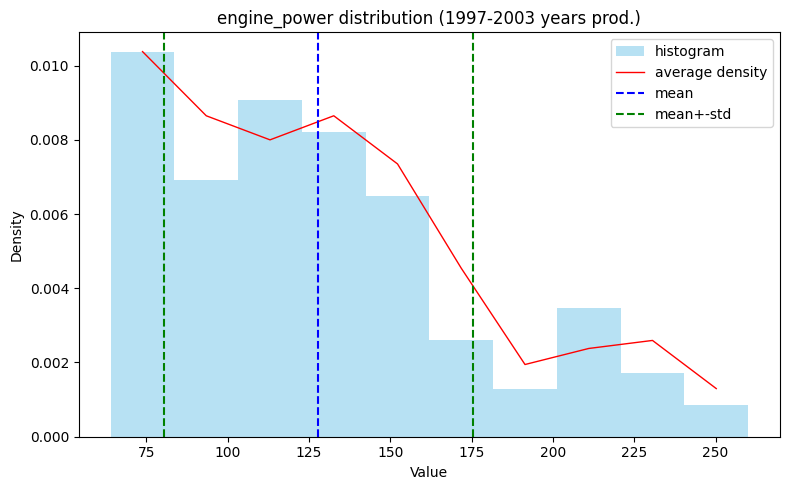

In [274]:
show_distribution(bulls_df, 'engine_power', 2000, 6)

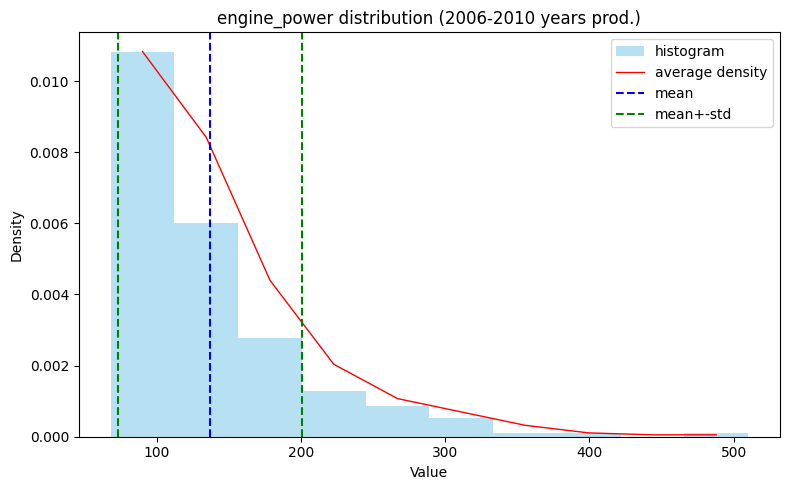

In [275]:
show_distribution(bulls_df, 'engine_power', 2008, 5)

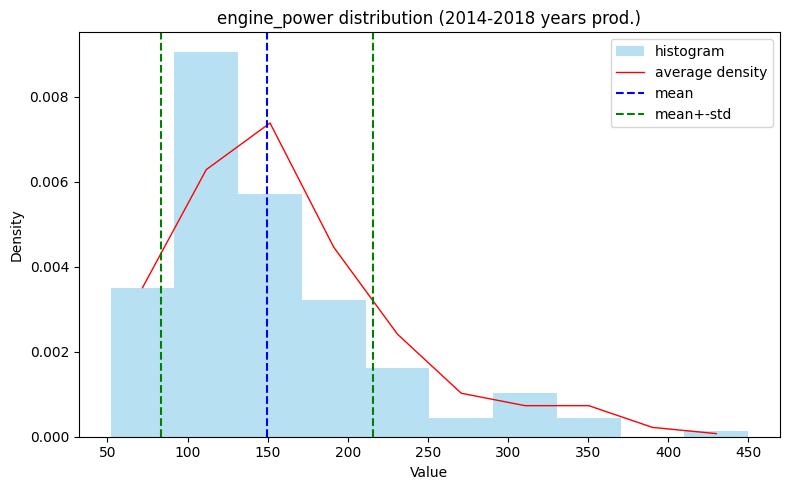

In [276]:
show_distribution(bulls_df, 'engine_power', 2016, 5)

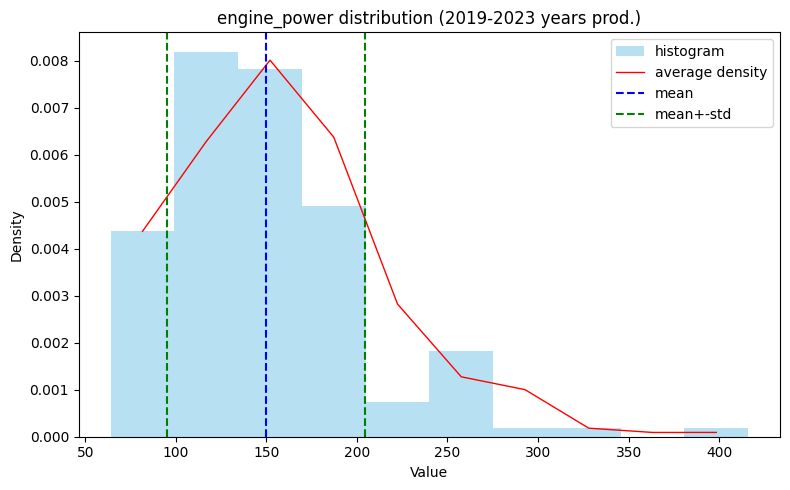

In [277]:
show_distribution(bulls_df, 'engine_power', 2021, 5)

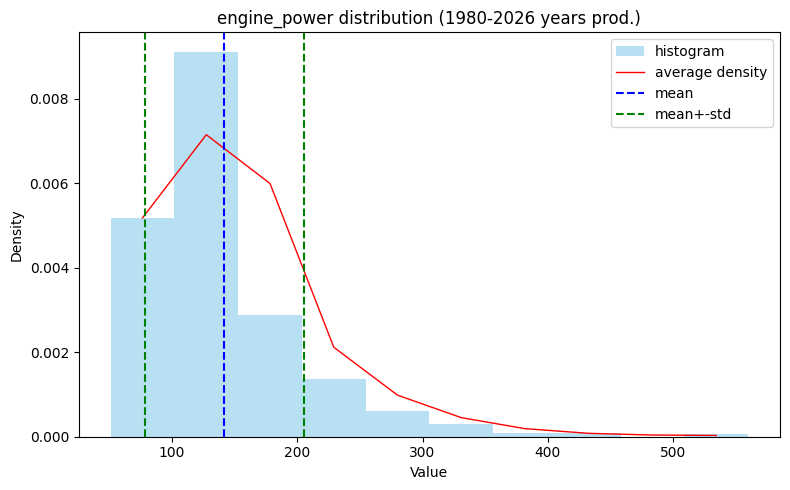

In [278]:
show_distribution(bulls_df, 'engine_power', 2003, 46)

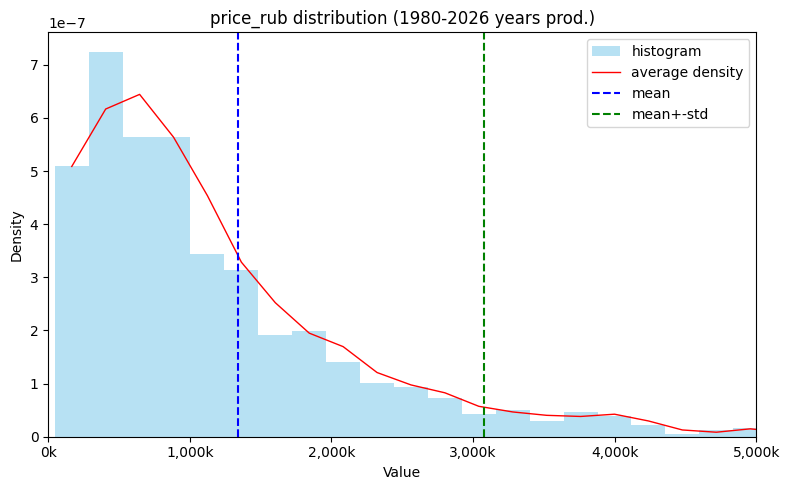

In [279]:
def thousands_formatter(x, pos):
    return f'{x/1000:,.0f}k' 

show_distribution(bulls_df, 'price_rub', 2003, 46, n_bins=100, formatter=thousands_formatter, xmax=5000000)

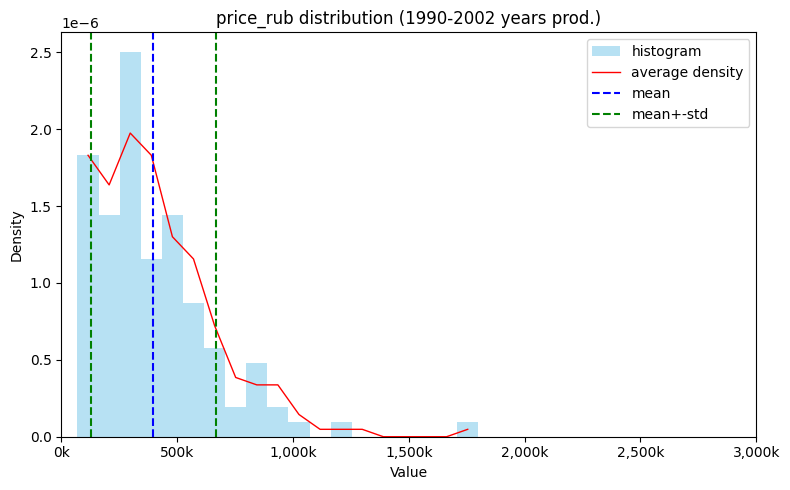

In [280]:
show_distribution(bulls_df, 'price_rub', 1996, 12, n_bins=19, formatter=thousands_formatter, xmax=3000000)

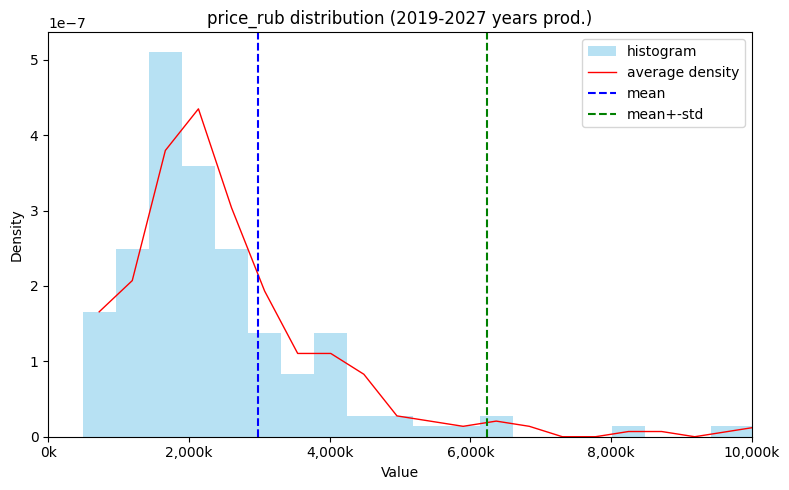

In [281]:
show_distribution(bulls_df, 'price_rub', 2023, 8, n_bins=50, formatter=thousands_formatter, xmax=10000000)

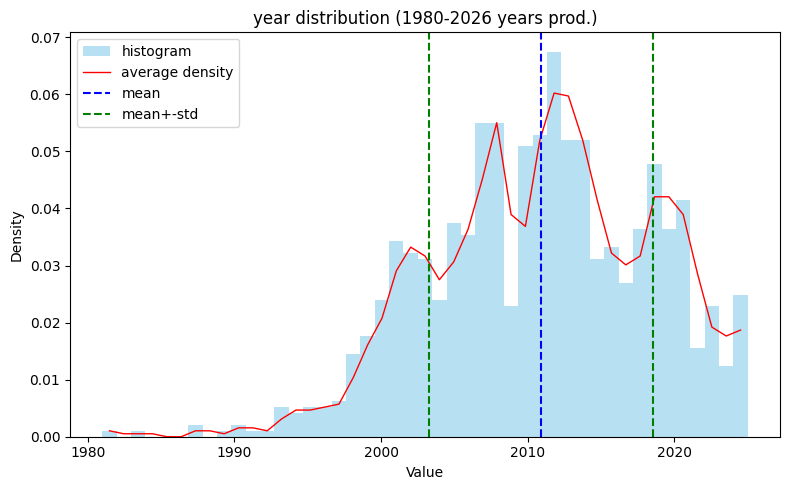

In [288]:
show_distribution(bulls_df, 'year', 2003, 46, n_bins=45)

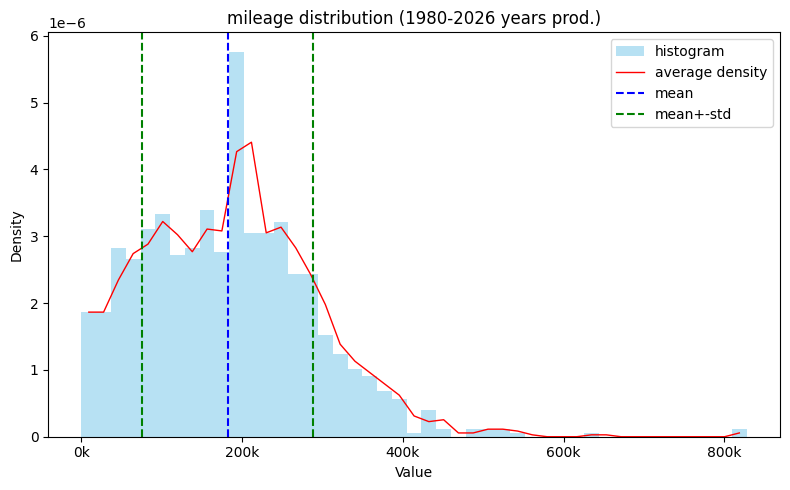

In [289]:
show_distribution(bulls_df, 'mileage', 2003, 46, n_bins=45, formatter=thousands_formatter)

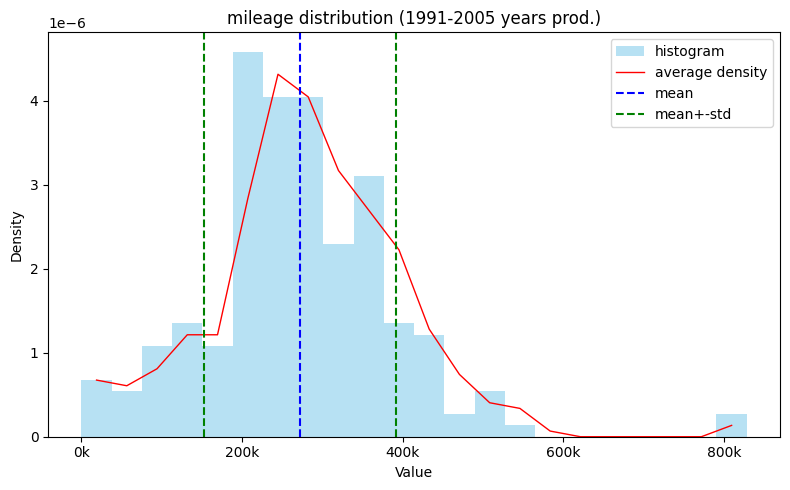

In [308]:
show_distribution(bulls_df, 'mileage', 1998, 14, n_bins=22, formatter=thousands_formatter)

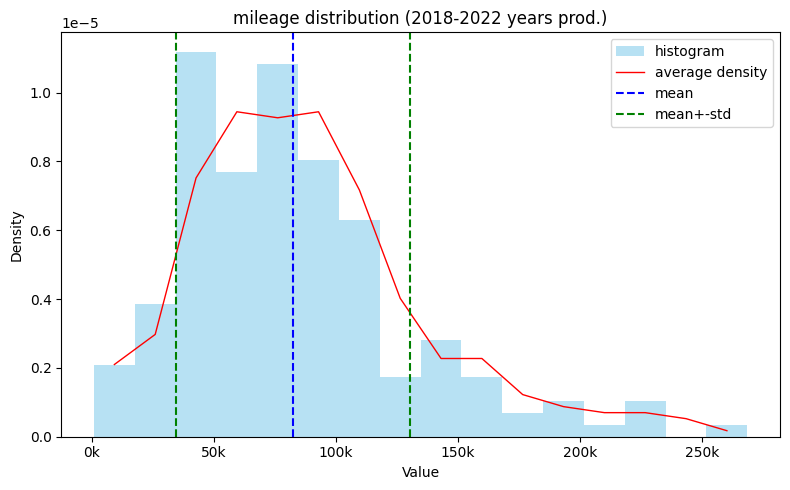

In [309]:
show_distribution(bulls_df, 'mileage', 2020, 5, n_bins=16, formatter=thousands_formatter)

In [381]:
colors = {"бежевый": "beige", 
                 "белый": "#F4F4F4", 
                 "бордовый": "#800020", 
                 "голубой": "skyblue", 
                 "желтый": "yellow", 
                 "зеленый": "green", 
                 "золотистый": "gold", 
                 "коричневый": "brown", 
                 "красный": "red", 
                 "оранжевый": "orange", 
                 "розовый": "pink", 
                 "серебристый": "silver", 
                 "серый": "grey", 
                 "синий": "blue", 
                 "фиолетовый": "purple", 
                 "черный": "black"}

In [2]:
def show_colors_pie(df, year_start, year_end):
    plt.close()
    bulls_df = df.query("year > @year_start and year < @year_end")
    color_scheme = list(map(lambda x: colors[x], pd.Series(bulls_df['color'].unique().dropna()).sort_values().to_list()))
    print(color_scheme)
    patches, _ = plt.pie(bulls_df.groupby('color').size().sort_index().to_list(),
       colors=color_scheme,
        startangle=0)

    plt.show()

In [3]:
show_colors_pie(bulls_df, 2008, 2026)

NameError: name 'bulls_df' is not defined

In [1]:
show_colors_pie(bulls_df, 1980, 1999);

NameError: name 'show_colors_pie' is not defined